# Question 1

## Q1.1: Study Objective

### Business Problem:
Mutuka Automotive needs an automated vehicle valuation system because manual pricing is time-consuming and inconsistent.

### Analytical Task:
Build a regression model that predicts vehicle price based on specifications, and create decision rules to identify which vehicles should be priced automatically vs manually reviewed.

### Success Metrics:
- Prediction error < R5,000 RMSE for 75%+ of vehicles
- Clear identification of vehicle segments where model is reliable
- Decision framework that flags high-risk cases for manual review

### Measurable KPIs:
| KPI | Target | Business Impact |
|-----|--------|-----------------|
| RMSE | < R5,000 | Trustworthy estimates |
| R² | > 0.80 | Explains 80% of price variance |
| Manual Review Rate | < 25% | Saves staff time |

### Libraries and Dataset

In [17]:
# Q1.1: Business Objective Definition
# Mutuka Automotive - Vehicle Valuation System

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs('output', exist_ok=True)



In [3]:
# Load the dataset
df = pd.read_csv(r"C:\Users\KHABAZELA\OneDrive\Desktop\Car_prices_ITSCA_Project\Dataset\car_pricing_datasets.csv")

# Quick look at the data
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Dataset shape: (205, 26)

First 5 rows:


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1.0,3.0,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130.0,mpfi,3.47,2.68,9.0,111.0,5000.0,21.0,27.0,269900.0
1,2.0,3.0,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130.0,mpfi,3.47,2.68,9.0,111.0,5000.0,21.0,27.0,330000.0
2,3.0,1.0,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152.0,mpfi,2.68,3.47,9.0,154.0,5000.0,19.0,26.0,330000.0
3,4.0,2.0,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109.0,mpfi,3.19,3.40,10.0,102.0,5500.0,24.0,30.0,279000.0
4,5.0,2.0,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136.0,mpfi,3.19,3.40,8.0,115.0,5500.0,18.0,22.0,349000.0


In [4]:
df.shape

(205, 26)

### 1.2 Data Quality

In [5]:
# Check for missing values
print(df.isnull().sum())

car_ID               9
symboling            6
CarName              7
fueltype            10
aspiration           2
doornumber           7
carbody             16
drivewheel           4
enginelocation       4
wheelbase            5
carlength           12
carwidth             7
carheight            3
curbweight           7
enginetype           2
cylindernumber      10
enginesize           9
fuelsystem           6
boreratio            7
stroke               8
compressionratio     6
horsepower           5
peakrpm              6
citympg              8
highwaympg          14
price                0
dtype: int64


In [6]:
# Check for duplicates
print(f"Duplicates: {df.duplicated().sum()}")

Duplicates: 0


In [7]:
# Check data types
print(df.dtypes)


car_ID              float64
symboling           float64
CarName              object
fueltype             object
aspiration           object
doornumber           object
carbody              object
drivewheel           object
enginelocation       object
wheelbase           float64
carlength           float64
carwidth            float64
carheight           float64
curbweight          float64
enginetype           object
cylindernumber       object
enginesize          float64
fuelsystem           object
boreratio           float64
stroke              float64
compressionratio    float64
horsepower          float64
peakrpm             float64
citympg             float64
highwaympg          float64
price               float64
dtype: object


In [8]:
# Check for weird values
print(df.describe())

           car_ID   symboling  wheelbase   carlength    carwidth   carheight  \
count  196.000000  199.000000  200.00000  193.000000  198.000000  202.000000   
mean   102.826531    0.829146   98.75050  173.904663   65.923232   53.747030   
std     59.129588    1.243551    6.03504   12.220766    2.165832    2.442313   
min      1.000000   -2.000000   86.60000  141.100000   60.300000   47.800000   
25%     52.750000    0.000000   94.50000  166.800000   64.100000   52.000000   
50%    102.500000    1.000000   96.90000  173.200000   65.500000   54.100000   
75%    154.250000    2.000000  101.40000  181.700000   66.825000   55.500000   
max    205.000000    3.000000  120.90000  208.100000   72.300000   59.800000   

        curbweight  enginesize   boreratio      stroke  compressionratio  \
count   198.000000   196.00000  198.000000  197.000000        199.000000   
mean   2557.308081   126.77551    3.335051    3.255025         10.124724   
std     525.421591    41.71270    0.271180    0.313

In [ ]:
#  Check categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
print("\nCategorical columns and unique values:")
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values")


Categorical columns and unique values:
CarName: 142 unique values
fueltype: 2 unique values
aspiration: 2 unique values
doornumber: 2 unique values
carbody: 5 unique values
drivewheel: 3 unique values
enginelocation: 2 unique values
enginetype: 7 unique values
cylindernumber: 7 unique values
fuelsystem: 8 unique values


In [10]:
# Check original size
print("Original rows:", len(df))

# Drop rows with missing values
df_clean = df.dropna()

# Check new size
print("Rows after dropping missing values:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

# Verify no missing values left
print("\nMissing values check:")
print(df_clean.isnull().sum().sum())  # Should be 0

Original rows: 205
Rows after dropping missing values: 169
Rows removed: 36

Missing values check:
0


##  Data Quality Assessment

### Missing Values
- Found missing values in most columns, with up to 14 missing in `highwaympg`.
- `price` had no missing values, which is essential for our target variable.
- Dropped all 36 rows with missing values. Remaining dataset: 169 rows, 26 columns.

### Duplicates
- No duplicate rows found. Each car is unique.

### Data Types
- Numeric columns are `float64` - suitable for modelling.
- Categorical columns are `object` - need encoding later (Question 3).
- `car_ID` is numeric but not a predictor; we will drop it when modelling.

### Extreme Values
- Prices range from R102,360 to R908,000. No obvious unrealistic values.
- Engine sizes range from 61 to 326 (reasonable).
- Horsepower ranges from 48 to 288 (reasonable).

### Justification of Decisions
- Dropping rows with missing values is safe because only 17.5% of rows were affected.
- This keeps the dataset simple and avoids introducing bias from imputation.



### 1.3 EDA Charts

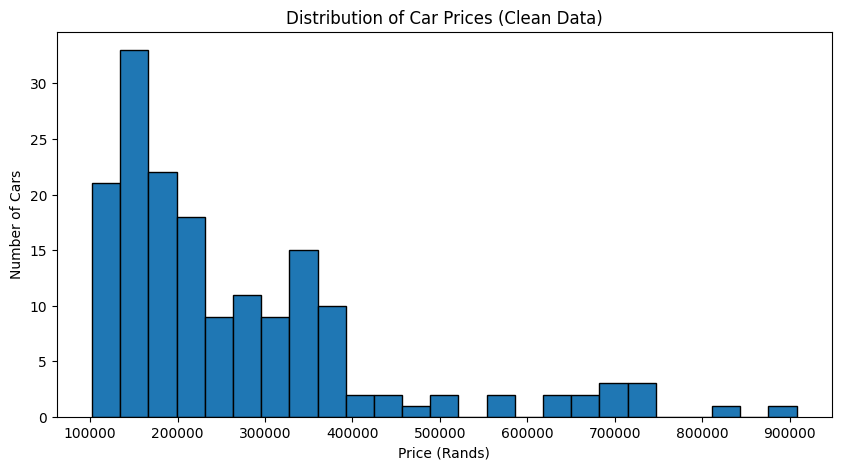

In [23]:
# clean dataset
df = df_clean.copy()

# Chart 1: Price distribution
plt.figure(figsize=(10,5))
plt.hist(df['price'], bins=25, edgecolor='black')
plt.title('Distribution of Car Prices (Clean Data)')
plt.xlabel('Price (Rands)')
plt.ylabel('Number of Cars')
plt.savefig('output/price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()



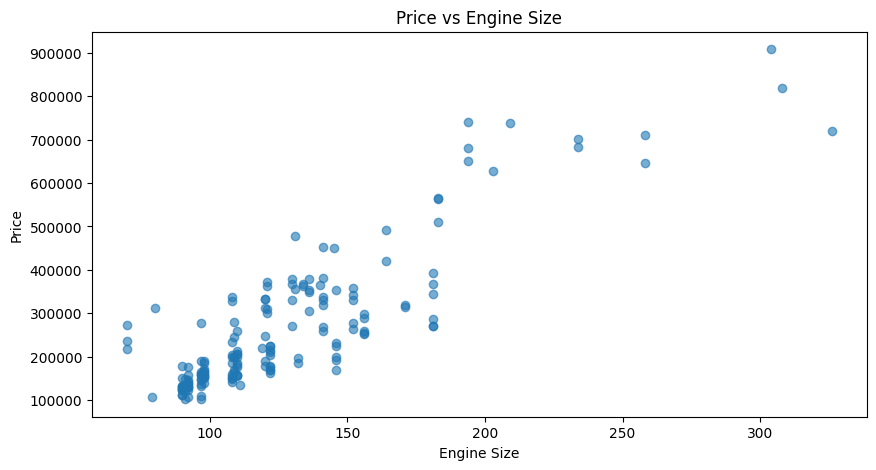

In [24]:
# Chart 2: Price vs Engine Size
plt.figure(figsize=(10,5))
plt.scatter(df['enginesize'], df['price'], alpha=0.6)
plt.title('Price vs Engine Size')
plt.xlabel('Engine Size')
plt.ylabel('Price')
plt.savefig('output/price_vs_engine.png', dpi=150, bbox_inches='tight')
plt.show()



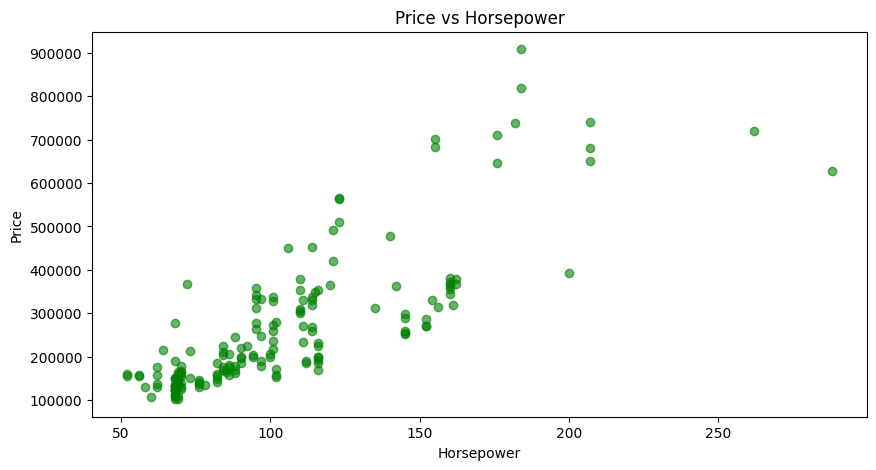

In [25]:
# Chart 3: Price vs Horsepower
plt.figure(figsize=(10,5))
plt.scatter(df['horsepower'], df['price'], alpha=0.6, color='green')
plt.title('Price vs Horsepower')
plt.xlabel('Horsepower')
plt.ylabel('Price')
plt.savefig('output/price_vs_horsepower.png', dpi=150, bbox_inches='tight')
plt.show()



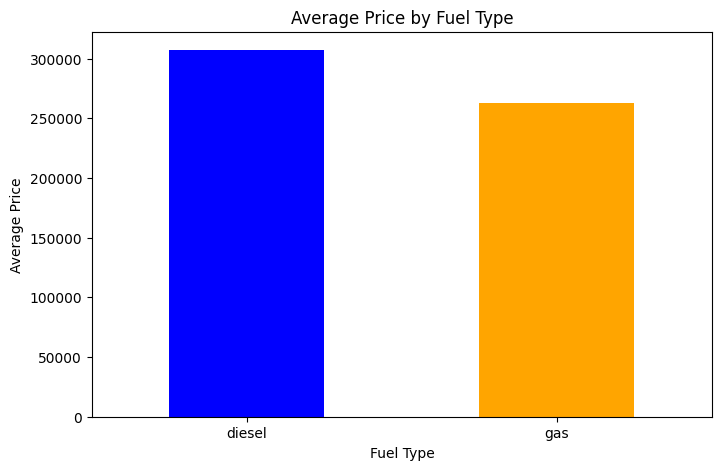

In [26]:
# Chart 4: Average price by fuel type
avg_by_fuel = df.groupby('fueltype')['price'].mean()
plt.figure(figsize=(8,5))
avg_by_fuel.plot(kind='bar', color=['blue', 'orange'])
plt.title('Average Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Average Price')
plt.xticks(rotation=0)
plt.savefig('output/avg_price_fuel.png', dpi=150, bbox_inches='tight')
plt.show()



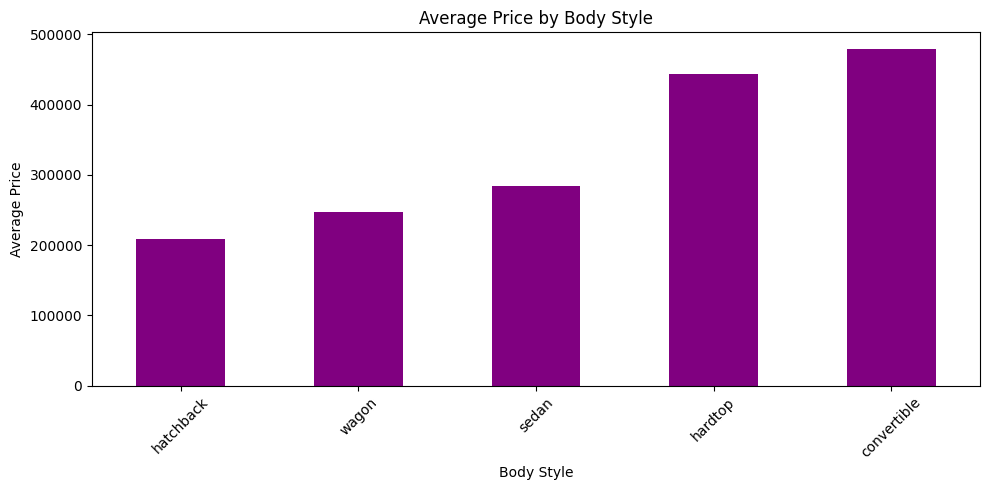

In [28]:
# Chart 5: Average price by body style (extra useful)
avg_by_body = df.groupby('carbody')['price'].mean().sort_values()
plt.figure(figsize=(10,5))
avg_by_body.plot(kind='bar', color='purple')
plt.title('Average Price by Body Style')
plt.xlabel('Body Style')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('output/avg_price_body.png', dpi=150, bbox_inches='tight')
plt.show()

##  Exploratory Data Analysis - Interpretation

### 1. Price Distribution
Most cars are priced between R150,000 and R350,000. The distribution is right-skewed, with fewer expensive cars above R600,000. This tells us the market has more affordable cars than luxury cars.

### 2. Price vs Engine Size
There is a clear positive relationship: as engine size increases, price increases. This makes sense because bigger engines mean more power and higher value. This will be a useful predictor for our model.

### 3. Price vs Horsepower
Similarly, higher horsepower cars tend to cost more. The relationship looks roughly linear, so this will also be a good predictor.

### 4. Average Price by Fuel Type
Diesel cars cost significantly more than petrol/gas cars on average. This is likely because diesel engines are often found in larger, more premium vehicles.

### 5. Average Price by Body Style
Convertibles and hardtops are the most expensive body styles. Hatchbacks and wagons are the cheapest. This reflects buyer preferences and market demand.

### Key Takeaways for Modelling
- Engine size, horsepower, fuel type, and body style are strong predictors of price.
- Price is continuous, so we will use regression models.
- Linear relationships suggest simple models may work, but outliers suggest we may need flexible models too.